<a href="https://colab.research.google.com/github/brunopn-code/bank-marketing-propensity/blob/main/notebooks/02_exploratory_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#EDA

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [68]:
df = pd.read_csv("bank_marketing_clean.csv")

In [69]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y,target
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0


In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp_var_rate    41188 non-null  float64
 16  cons_price_idx  41188 non-null  float64
 17  cons_conf_idx   41188 non-null 

-----

## Target Distribution

Before analyzing client and campaign variables, we first inspect the target variable.

The target variable `y` indicates whether the client subscribed to a term deposit. Since marketing campaign datasets are often imbalanced, checking the proportion of positive and negative responses is important before modeling.

In [71]:
target_counts = df["y"].value_counts()
target_rates = df["y"].value_counts(normalize=True).round(4) * 100

target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": target_rates
})

target_summary

,count,percentage
y,,
no,36548,88.73
yes,4640,11.27


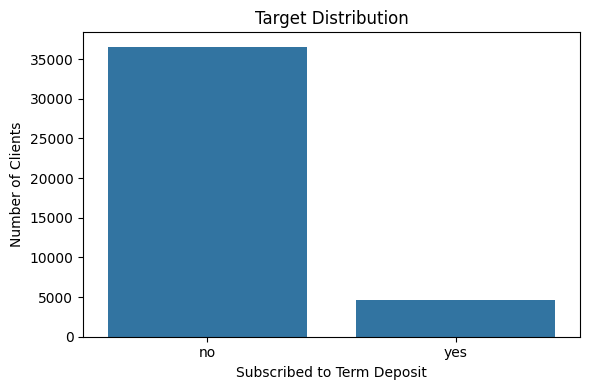

In [72]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="y")
plt.title("Target Distribution")
plt.xlabel("Subscribed to Term Deposit")
plt.ylabel("Number of Clients")
plt.tight_layout()
plt.show()

#Target distribution findings

The dataset is imbalanced. Most clients did not subscribe to the term deposit, while only a smaller percentage subscribed.

This means that accuracy alone will not be enough to evaluate the machine learning models. A model could achieve high accuracy by mostly predicting the majority class. For this reason, as said in the previous notebook, the modeling stage should also use precision, recall, F1-score, ROC-AUC, and confusion matrix.

------

## Subscription Rate by Client Profile

Next, we analyze whether subscription rates differ across client characteristics such as job, education, marital status, and age.

This helps identify which types of clients appear more likely to subscribe to a term deposit.

In [73]:
#function to create an aggregate by variables
def subscription_rate_by_category(df, column):
    summary = (
        df.groupby(column)
        .agg(
            total_clients=("target", "count"),
            subscribed_clients=("target", "sum"),
            subscription_rate=("target", "mean")
        )
        .reset_index()
    )

    summary["subscription_rate"] = (summary["subscription_rate"] * 100).round(2)

    return summary.sort_values("subscription_rate", ascending=False)

In [74]:
job_subscription = subscription_rate_by_category(df, "job")
job_subscription

,job,total_clients,subscribed_clients,subscription_rate
8,student,875,275,31.43
5,retired,1720,434,25.23
10,unemployed,1014,144,14.20
0,admin.,10422,1352,12.97
4,management,2924,328,11.22
11,unknown,330,37,11.21
9,technician,6743,730,10.83
6,self-employed,1421,149,10.49
3,housemaid,1060,106,10.00
2,entrepreneur,1456,124,8.52


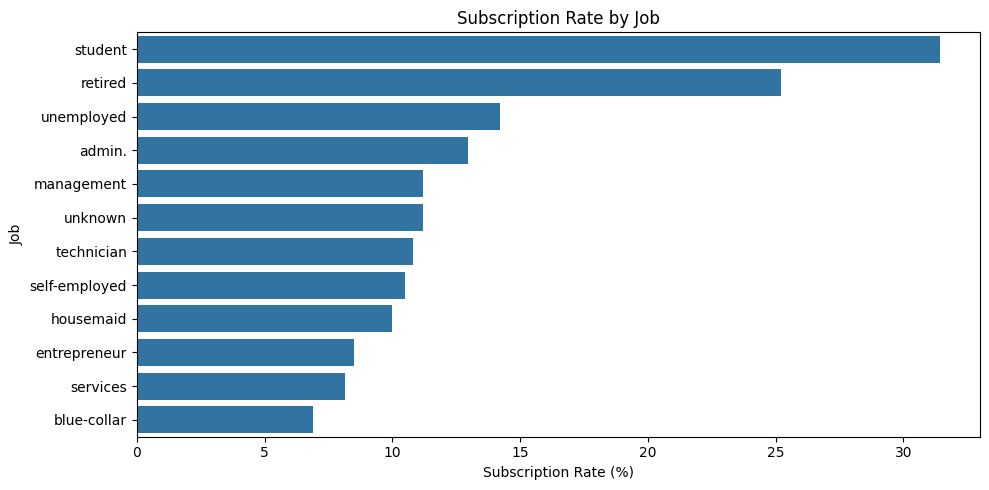

In [75]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=job_subscription,
    x="subscription_rate",
    y="job"
)
plt.title("Subscription Rate by Job")
plt.xlabel("Subscription Rate (%)")
plt.ylabel("Job")
plt.tight_layout()
plt.savefig("eda_subscription_rate_by_job.png", dpi=300, bbox_inches="tight")
plt.show()

In [76]:
education_subscription = subscription_rate_by_category(df, "education")
education_subscription

,education,total_clients,subscribed_clients,subscription_rate
4,illiterate,18,4,22.22
7,unknown,1731,251,14.50
6,university.degree,12168,1670,13.72
5,professional.course,5243,595,11.35
3,high.school,9515,1031,10.84
0,basic.4y,4176,428,10.25
1,basic.6y,2292,188,8.20
2,basic.9y,6045,473,7.82


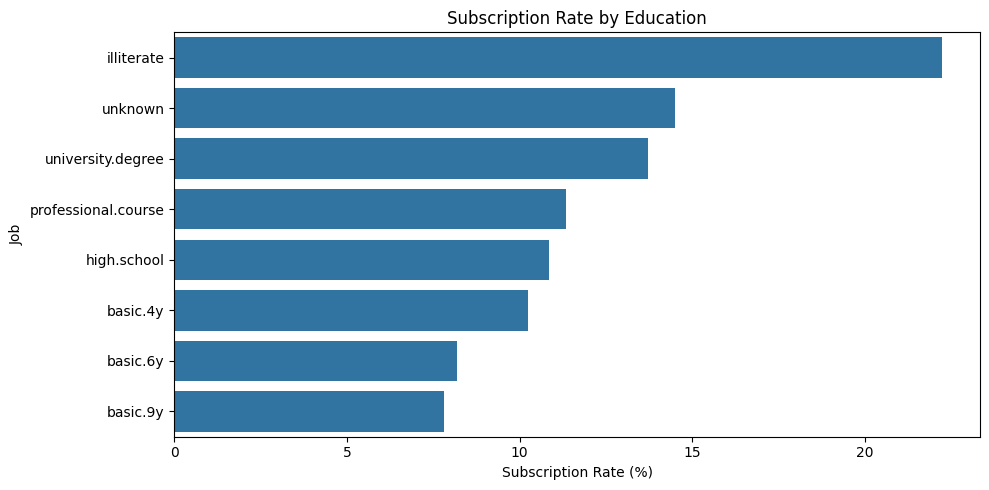

In [77]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=education_subscription,
    x="subscription_rate",
    y="education"
)
plt.title("Subscription Rate by Education")
plt.xlabel("Subscription Rate (%)")
plt.ylabel("Job")
plt.tight_layout()
plt.savefig("eda_subscription_rate_by_education.png", dpi=300, bbox_inches="tight")
plt.show()

In [78]:
marital_subscription = subscription_rate_by_category(df, "marital")
marital_subscription

,marital,total_clients,subscribed_clients,subscription_rate
3,unknown,80,12,15.00
2,single,11568,1620,14.00
0,divorced,4612,476,10.32
1,married,24928,2532,10.16


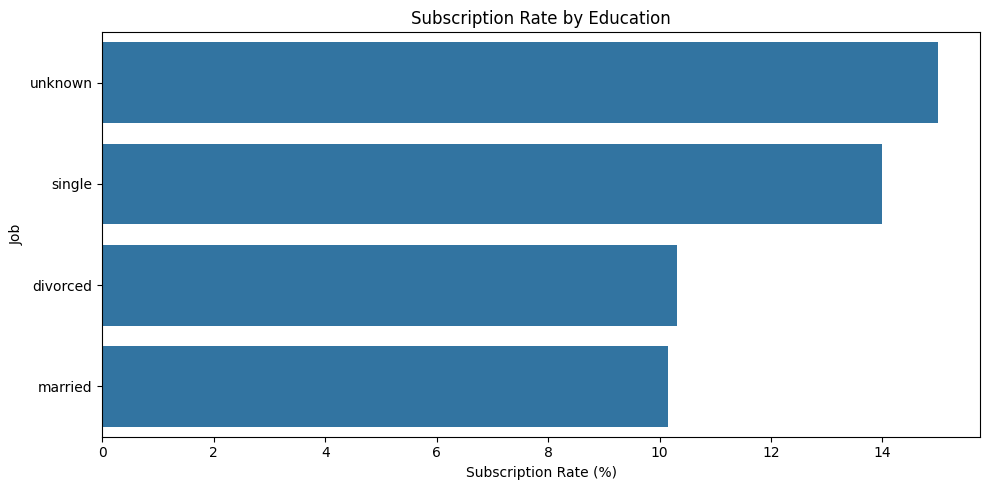

In [79]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=marital_subscription,
    x="subscription_rate",
    y="marital"
)
plt.title("Subscription Rate by Education")
plt.xlabel("Subscription Rate (%)")
plt.ylabel("Job")
plt.tight_layout()
plt.savefig("eda_subscription_rate_by_education.png", dpi=300, bbox_inches="tight")
plt.show()

### Client Profile Findings

Subscription rates vary noticeably across client profile groups.

By job, `student` clients have the highest subscription rate at 31.43%, followed by `retired` clients at 25.23%. In contrast, `blue-collar` clients have the lowest subscription rate at 6.89%, followed by `services` at 8.14% and `entrepreneur` at 8.52%.

By education, `university.degree` clients have a higher subscription rate than most basic education groups. The `illiterate` category shows a high subscription rate, but it contains only 18 clients, so it should not be interpreted as a reliable pattern.

By marital status, `single` clients have a higher subscription rate than married and divorced clients. The `unknown` marital category also has a higher rate, but it contains only 80 clients, so it should be interpreted carefully.

Overall, these results suggest that client profile variables such as job, education, and marital status are associated with subscription behavior. These relationships should be examined further during the modeling phase using statistical association analysis and feature importance methods.


------

## Age Distribution

Before creating age groups, we first inspect the distribution of the `age` variable.

This helps avoid defining arbitrary age ranges without understanding the actual spread of the data. Summary statistics, a histogram, and boxplots are used to identify the typical age range, median age, variation, and possible outliers.

Older clients should not be removed automatically, because they may represent valid customer segments and could be relevant for subscription behavior.


In [80]:
df["age"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

,age
count,41188.00000
mean,40.02406
std,10.42125
min,17.00000
1%,23.00000
5%,26.00000
25%,32.00000
50%,38.00000
75%,47.00000
95%,58.00000


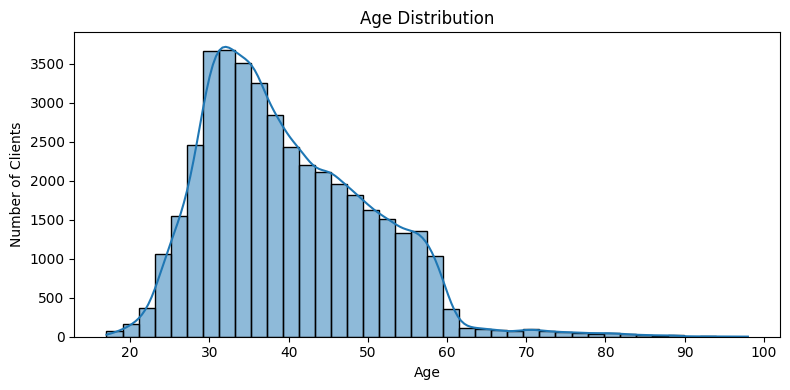

In [81]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x="age", bins=40, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Clients")
plt.tight_layout()
plt.savefig("eda_age_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

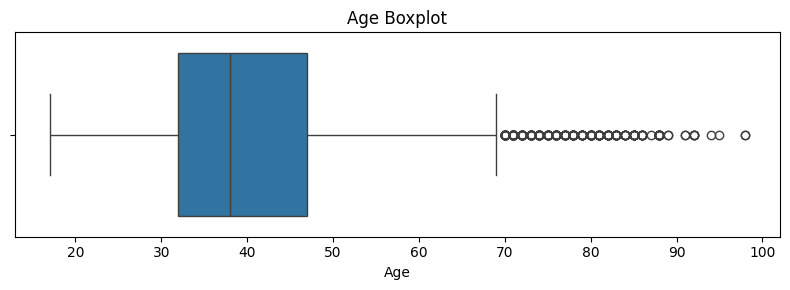

In [82]:
plt.figure(figsize=(8, 3))
sns.boxplot(data=df, x="age")
plt.title("Age Boxplot")
plt.xlabel("Age")
plt.tight_layout()
plt.savefig("eda_age_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

### Age Distribution Findings

The age distribution is right-skewed, with most clients concentrated between their early 30s and late 40s. The median age is 38, and 75% of clients are 47 years old or younger.

There is a smaller group of older clients, with values above 70 appearing as outliers in the boxplot. These observations should not be removed automatically because they are valid client records and may represent an important customer segment.

Based on the distribution, age groups were created to separate younger clients, the main working-age population, and older clients.


In [83]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 30, 40, 50, 60, 70, 100],
    labels=["Under 30", "30-39", "40-49", "50-59", "60-69", "70+"],
    right=False
)

In [84]:
df["age_group"].value_counts().sort_index()

,count
age_group,
Under 30,5669
30-39,16938
40-49,10526
50-59,6862
60-69,724
70+,469


In [85]:
age_subscription = subscription_rate_by_category(df, "age_group")
age_subscription

/tmp/ipykernel_2984/3266010432.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(column)


,age_group,total_clients,subscribed_clients,subscription_rate
5,70+,469,221,47.12
4,60-69,724,251,34.67
0,Under 30,5669,922,16.26
3,50-59,6862,697,10.16
1,30-39,16938,1715,10.13
2,40-49,10526,834,7.92


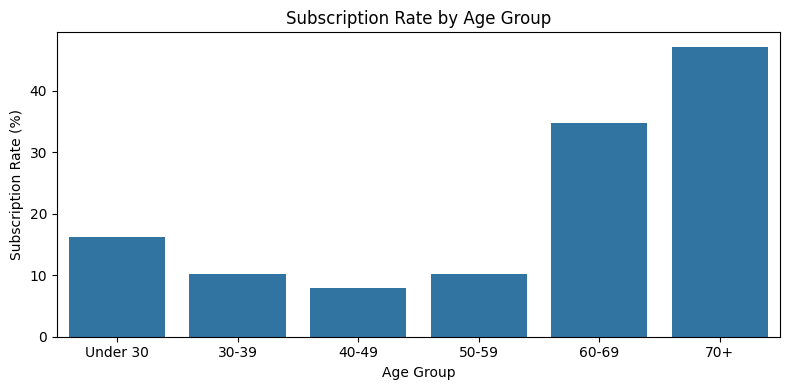

In [86]:
plt.figure(figsize=(8, 4))
sns.barplot(
    data=age_subscription.sort_values("age_group"),
    x="age_group",
    y="subscription_rate"
)
plt.title("Subscription Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Subscription Rate (%)")
plt.tight_layout()
plt.savefig("eda_subscription_rate_by_age_group.png", dpi=300, bbox_inches="tight")
plt.show()

### Age Group Findings

Subscription rates vary strongly by age group.

Clients aged `70+` have the highest subscription rate at 47.12%, followed by clients aged `60-69` at 34.67%. Younger clients under 30 also show a higher-than-average subscription rate at 16.26%.

In contrast, the main working-age groups between 30 and 59 have lower subscription rates, especially the `40-49` group, which has the lowest subscription rate at 7.92%.

Together with the job-based analysis, this suggests that students and retired clients are more likely to subscribe than the main working-age population. This should be interpreted as an association rather than a causal conclusion, because age and job are related variables and may interact with other campaign and economic factors.

-----

## Campaign and Contact Variables

After analyzing client profile variables, we now examine campaign-related variables.

These features describe how the client was contacted, when the contact happened, how many contacts were made during the campaign, and whether the client had previous campaign interactions.

This section helps identify marketing conditions associated with higher subscription rates.


In [87]:
contact_subscription = subscription_rate_by_category(df, "contact")
contact_subscription

,contact,total_clients,subscribed_clients,subscription_rate
0,cellular,26144,3853,14.74
1,telephone,15044,787,5.23


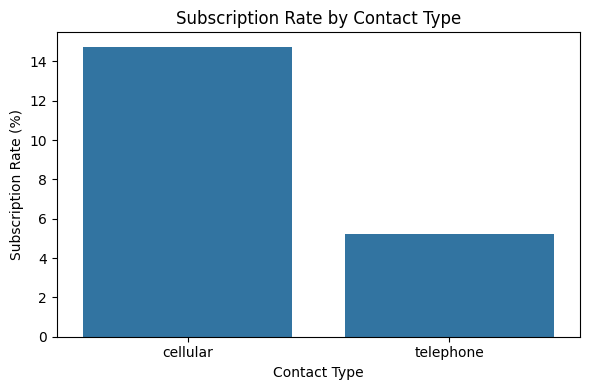

In [88]:
plt.figure(figsize=(6, 4))
sns.barplot(
    data=contact_subscription,
    x="contact",
    y="subscription_rate"
)
plt.title("Subscription Rate by Contact Type")
plt.xlabel("Contact Type")
plt.ylabel("Subscription Rate (%)")
plt.tight_layout()
plt.savefig("eda_subscription_rate_by_contact.png", dpi=300, bbox_inches="tight")
plt.show()

In [89]:
month_subscription = subscription_rate_by_category(df, "month")
month_subscription

,month,total_clients,subscribed_clients,subscription_rate
5,mar,546,276,50.55
2,dec,182,89,48.90
9,sep,570,256,44.91
8,oct,718,315,43.87
0,apr,2632,539,20.48
1,aug,6178,655,10.60
4,jun,5318,559,10.51
7,nov,4101,416,10.14
3,jul,7174,649,9.05
6,may,13769,886,6.43


In [90]:
month_order = ["mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"]

month_subscription["month"] = pd.Categorical(
    month_subscription["month"],
    categories=month_order,
    ordered=True
)

month_subscription = month_subscription.sort_values("month")

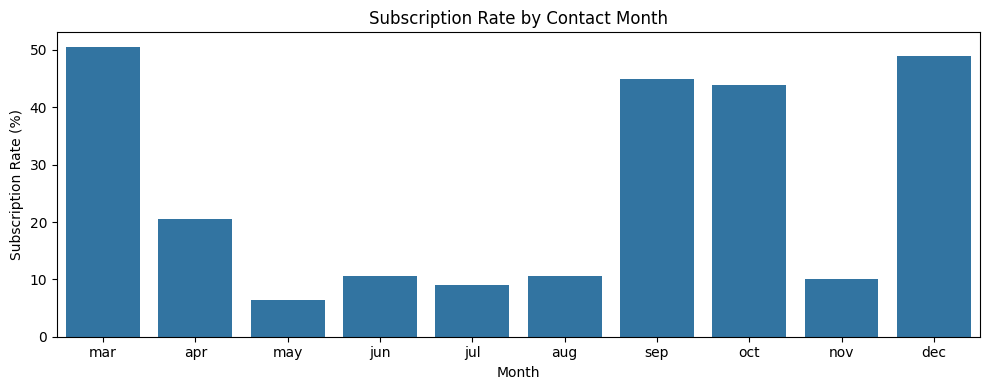

In [91]:
plt.figure(figsize=(10, 4))
sns.barplot(
    data=month_subscription,
    x="month",
    y="subscription_rate"
)
plt.title("Subscription Rate by Contact Month")
plt.xlabel("Month")
plt.ylabel("Subscription Rate (%)")
plt.tight_layout()
plt.savefig("eda_subscription_rate_by_month.png", dpi=300, bbox_inches="tight")
plt.show()

In [92]:
poutcome_subscription = subscription_rate_by_category(df, "poutcome")
poutcome_subscription

,poutcome,total_clients,subscribed_clients,subscription_rate
2,success,1373,894,65.11
0,failure,4252,605,14.23
1,nonexistent,35563,3141,8.83


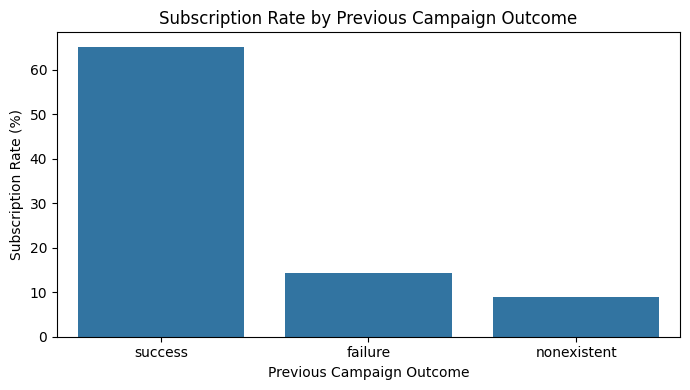

In [93]:
plt.figure(figsize=(7, 4))
sns.barplot(
    data=poutcome_subscription,
    x="poutcome",
    y="subscription_rate"
)
plt.title("Subscription Rate by Previous Campaign Outcome")
plt.xlabel("Previous Campaign Outcome")
plt.ylabel("Subscription Rate (%)")
plt.tight_layout()
plt.savefig("eda_subscription_rate_by_poutcome.png", dpi=300, bbox_inches="tight")
plt.show()

In [94]:
df["campaign"].describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99])

,campaign
count,41188.000000
mean,2.567593
std,2.770014
min,1.000000
25%,1.000000
50%,2.000000
75%,3.000000
90%,5.000000
95%,7.000000
99%,14.000000


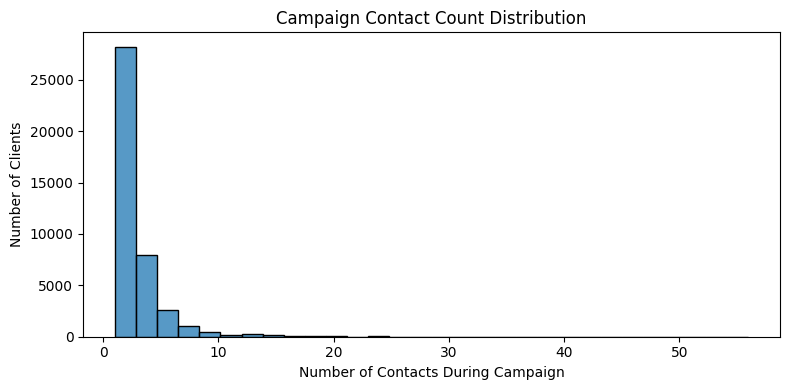

In [95]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x="campaign", bins=30)
plt.title("Campaign Contact Count Distribution")
plt.xlabel("Number of Contacts During Campaign")
plt.ylabel("Number of Clients")
plt.tight_layout()
plt.savefig("eda_campaign_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

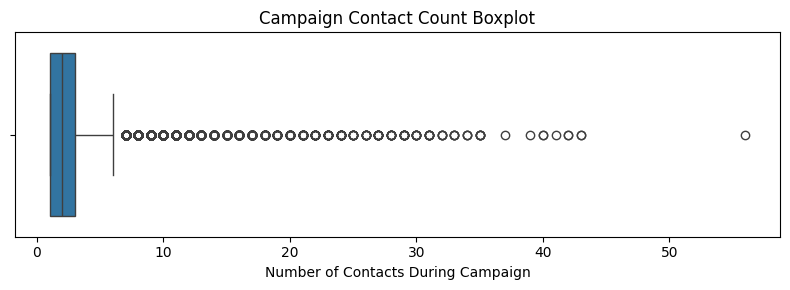

In [96]:
plt.figure(figsize=(8, 3))
sns.boxplot(data=df, x="campaign")
plt.title("Campaign Contact Count Boxplot")
plt.xlabel("Number of Contacts During Campaign")
plt.tight_layout()
plt.savefig("eda_campaign_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

In [97]:
df["campaign_group"] = pd.cut(
    df["campaign"],
    bins=[0, 1, 2, 3, 5, 14, 100],
    labels=["1 contact", "2 contacts", "3 contacts", "4-5 contacts", "6-14 contacts", "14+ contacts"],
    right=True
)

In [98]:
campaign_subscription = subscription_rate_by_category(df, "campaign_group")
campaign_subscription

/tmp/ipykernel_2984/3266010432.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(column)


,campaign_group,total_clients,subscribed_clients,subscription_rate
0,1 contact,17642,2300,13.04
1,2 contacts,10570,1211,11.46
2,3 contacts,5341,574,10.75
3,4-5 contacts,4250,369,8.68
4,6-14 contacts,2979,179,6.01
5,14+ contacts,406,7,1.72


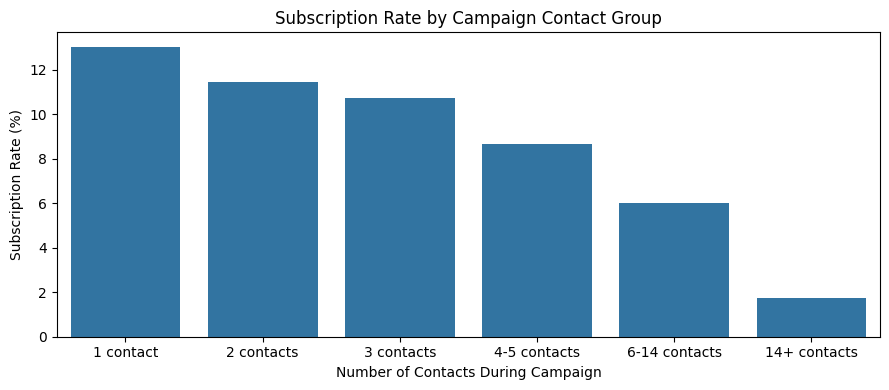

In [99]:
plt.figure(figsize=(9, 4))
sns.barplot(
    data=campaign_subscription.sort_values("campaign_group"),
    x="campaign_group",
    y="subscription_rate"
)
plt.title("Subscription Rate by Campaign Contact Group")
plt.xlabel("Number of Contacts During Campaign")
plt.ylabel("Subscription Rate (%)")
plt.tight_layout()
plt.savefig("eda_subscription_rate_by_campaign_group.png", dpi=300, bbox_inches="tight")
plt.show()

### Campaign and Contact Variable Findings

Campaign-related variables show clear differences in subscription rates.

Clients contacted by `cellular` have a higher subscription rate than clients contacted by `telephone`. This suggests that contact channel may be associated with campaign success.

Previous campaign outcome also shows a strong relationship with subscription. Clients with a previous campaign outcome of `success` have a much higher subscription rate than clients with `failure` or `nonexistent` previous outcomes. This suggests that past positive engagement is an important signal for future subscription behavior.

Subscription rates also vary strongly by month. The months `mar`, `dec`, `sep`, and `oct` show the highest subscription rates. However, these months contain fewer clients than high-volume months such as `may`, so this pattern should be interpreted carefully.

The number of campaign contacts shows an inverse relationship with subscription rate. Clients contacted once have the highest subscription rate, while clients contacted many times have much lower subscription rates. This may indicate that repeated contact attempts are associated with lower conversion probability. However, this should not be interpreted as a direct causal effect, because clients who are harder to convert may naturally receive more contact attempts.

Overall, these results suggest that contact type, contact month, previous campaign outcome, and number of campaign contacts are associated with subscription behavior. These relationships should be examined further using statistical association tests and model-based feature importance during the modeling phase.


-----